In [2]:
# Cell 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Cell 2: Load data
train_df = pd.read_csv('aug_train.csv')
test_df = pd.read_csv('aug_test.csv')

print(f"Training data: {train_df.shape}")
print(f"Test data: {test_df.shape}")

# Show sample
print("\nFirst 5 rows of training data:")
train_df.head()

Training data: (19158, 14)
Test data: (2129, 13)

First 5 rows of training data:


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
# Cell 3: Check data info
print("=== Training Data Info ===")
train_df.info()

print("\n=== Test Data Info ===")
test_df.info()

=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(

In [5]:
# Cell 4: Check missing values
missing_train = train_df.isnull().sum()
missing_train_percent = (missing_train / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing': missing_train,
    'Percentage': missing_train_percent
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print("=== Missing Values in Training Data ===")
print(missing_df)

print("\n=== Missing Values in Test Data ===")
missing_test = test_df.isnull().sum()
missing_test_percent = (missing_test / len(test_df)) * 100
missing_test_df = pd.DataFrame({
    'Missing': missing_test,
    'Percentage': missing_test_percent
})
missing_test_df = missing_test_df[missing_test_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(missing_test_df)

=== Missing Values in Training Data ===
                     Missing  Percentage
company_type            6140   32.049274
company_size            5938   30.994885
gender                  4508   23.530640
major_discipline        2813   14.683161
education_level          460    2.401086
last_new_job             423    2.207955
enrolled_university      386    2.014824
experience                65    0.339284

=== Missing Values in Test Data ===
                     Missing  Percentage
company_type             634   29.779239
company_size             622   29.215594
gender                   508   23.860968
major_discipline         312   14.654767
education_level           52    2.442461
last_new_job              40    1.878816
enrolled_university       31    1.456083
experience                 5    0.234852


Target distribution:
target
0.0    14381
1.0     4777
Name: count, dtype: int64

Percentages:
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


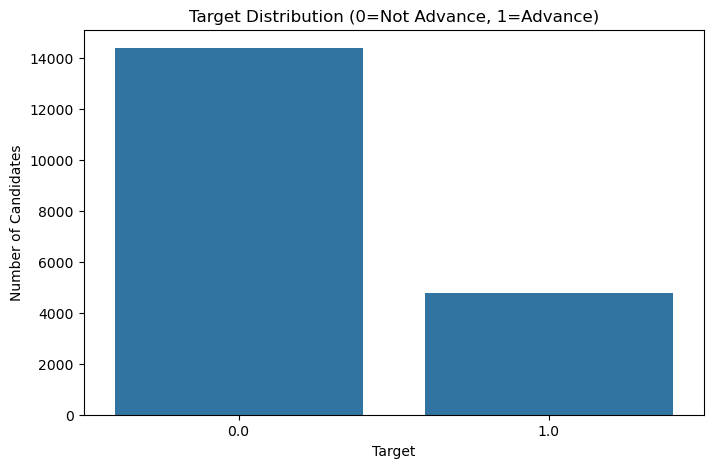

In [6]:
# Cell 5: Check target distribution
print("Target distribution:")
print(train_df['target'].value_counts())
print("\nPercentages:")
print(train_df['target'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='target')
plt.title('Target Distribution (0=Not Advance, 1=Advance)')
plt.xlabel('Target')
plt.ylabel('Number of Candidates')
plt.show()

In [7]:
# Cell 6: Explore categorical columns
categorical_cols = ['gender', 'relevent_experience', 'enrolled_university', 
                    'education_level', 'major_discipline', 'company_size', 
                    'company_type', 'last_new_job']

print("=== Categorical Columns Value Counts ===")
for col in categorical_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts(dropna=False))

=== Categorical Columns Value Counts ===

gender:
gender
Male      13221
NaN        4508
Female     1238
Other       191
Name: count, dtype: int64

relevent_experience:
relevent_experience
Has relevent experience    13792
No relevent experience      5366
Name: count, dtype: int64

enrolled_university:
enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
NaN                   386
Name: count, dtype: int64

education_level:
education_level
Graduate          11598
Masters            4361
High School        2017
NaN                 460
Phd                 414
Primary School      308
Name: count, dtype: int64

major_discipline:
major_discipline
STEM               14492
NaN                 2813
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

company_size:
company_size
NaN          5938
50-99        3083
100-500      2571
10000+       2019
10/49 

=== Numerical Columns Statistics ===
       city_development_index  training_hours
count            19158.000000    19158.000000
mean                 0.828848       65.366896
std                  0.123362       60.058462
min                  0.448000        1.000000
25%                  0.740000       23.000000
50%                  0.903000       47.000000
75%                  0.920000       88.000000
max                  0.949000      336.000000


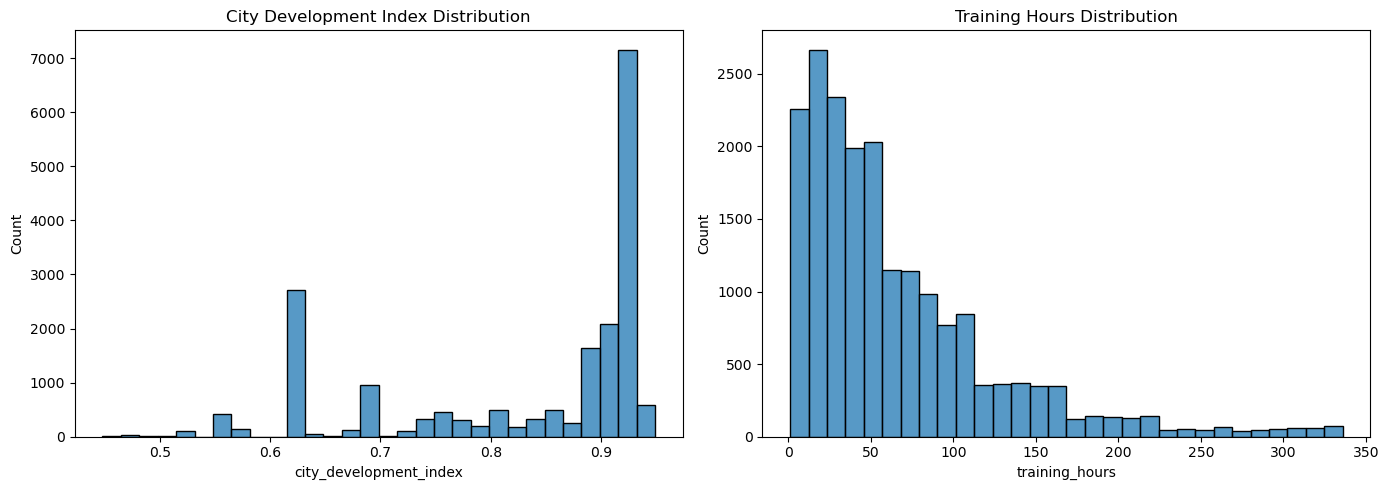

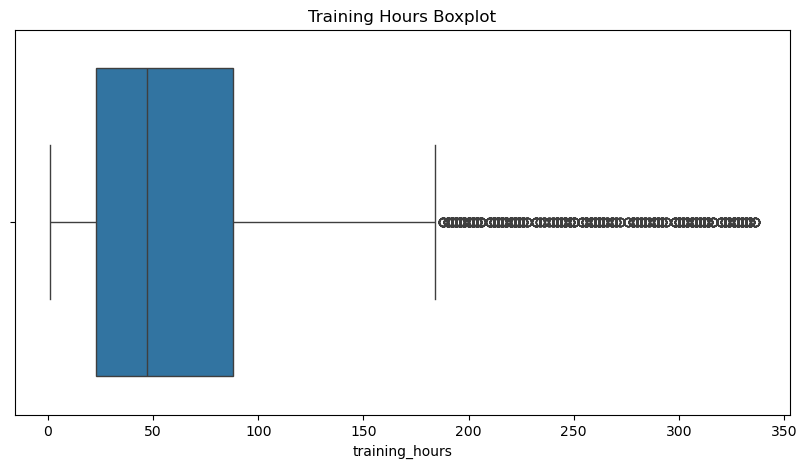

In [8]:
# Cell 7: Explore numerical columns
numerical_cols = ['city_development_index', 'training_hours']

print("=== Numerical Columns Statistics ===")
print(train_df[numerical_cols].describe())

# Visualize numerical columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# City Development Index
sns.histplot(train_df['city_development_index'], bins=30, ax=axes[0])
axes[0].set_title('City Development Index Distribution')

# Training Hours
sns.histplot(train_df['training_hours'], bins=30, ax=axes[1])
axes[1].set_title('Training Hours Distribution')

plt.tight_layout()
plt.show()

# Boxplot for training hours
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x='training_hours')
plt.title('Training Hours Boxplot')
plt.show()

In [9]:
# Cell 8: Clean experience column
def clean_experience(value):
    """
    Convert experience values to numeric
    <1 -> 0 (less than 1 year)
    >20 -> 21 (more than 20 years, cap at 21)
    """
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if '<' in text:
        return 0
    elif '>' in text:
        return 21
    else:
        try:
            return int(float(text))
        except:
            return np.nan

# Apply to both train and test
train_df['experience_cleaned'] = train_df['experience'].apply(clean_experience)
test_df['experience_cleaned'] = test_df['experience'].apply(clean_experience)

# Show results
print("Before cleaning:")
print(train_df[['experience']].head(10))
print("\nAfter cleaning:")
print(train_df[['experience', 'experience_cleaned']].head(10))

# Check statistics after cleaning
print("\nExperience cleaned statistics:")
print(train_df['experience_cleaned'].describe())

Before cleaning:
  experience
0        >20
1         15
2          5
3         <1
4        >20
5         11
6          5
7         13
8          7
9         17

After cleaning:
  experience  experience_cleaned
0        >20                21.0
1         15                15.0
2          5                 5.0
3         <1                 0.0
4        >20                21.0
5         11                11.0
6          5                 5.0
7         13                13.0
8          7                 7.0
9         17                17.0

Experience cleaned statistics:
count    19093.000000
mean        10.100141
std          6.777024
min          0.000000
25%          4.000000
50%          9.000000
75%         16.000000
max         21.000000
Name: experience_cleaned, dtype: float64


In [10]:
# Cell 9: Standardize text columns
def standardize_text(text):
    if pd.isna(text):
        return text
    return str(text).strip().lower()

text_columns = ['gender', 'relevent_experience', 'enrolled_university', 
                'education_level', 'major_discipline', 'company_size', 
                'company_type', 'last_new_job']

for col in text_columns:
    train_df[col] = train_df[col].apply(standardize_text)
    test_df[col] = test_df[col].apply(standardize_text)

print("✅ Text columns standardized")

✅ Text columns standardized


In [11]:
# Cell 10: Create new features (Feature Engineering)
# 1. Experience ratio (experience / city development index)
train_df['experience_ratio'] = train_df['experience_cleaned'] / (train_df['city_development_index'] + 0.1)
test_df['experience_ratio'] = test_df['experience_cleaned'] / (test_df['city_development_index'] + 0.1)

# 2. Training hours per experience
train_df['training_per_experience'] = train_df['training_hours'] / (train_df['experience_cleaned'] + 1)
test_df['training_per_experience'] = test_df['training_hours'] / (test_df['experience_cleaned'] + 1)

# 3. Has relevant experience (binary)
train_df['has_relevant_exp'] = (train_df['relevent_experience'] == 'has relevent experience').astype(int)
test_df['has_relevant_exp'] = (test_df['relevent_experience'] == 'has relevent experience').astype(int)

# 4. Categorize experience (optional)
def categorize_experience(exp):
    if pd.isna(exp):
        return 'unknown'
    elif exp <= 2:
        return 'junior'
    elif exp <= 5:
        return 'mid'
    elif exp <= 10:
        return 'senior'
    else:
        return 'expert'

train_df['exp_category'] = train_df['experience_cleaned'].apply(categorize_experience)
test_df['exp_category'] = test_df['experience_cleaned'].apply(categorize_experience)

print("✅ New features created:")
print("   - experience_ratio")
print("   - training_per_experience")
print("   - has_relevant_exp")
print("   - exp_category")

✅ New features created:
   - experience_ratio
   - training_per_experience
   - has_relevant_exp
   - exp_category


Training Hours Statistics:
count    19158.000000
mean        65.366896
std         60.058462
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

99th percentile of training_hours: 302.0

After capping:
count    19158.000000
mean        65.191095
std         59.326605
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        302.000000
Name: training_hours_capped, dtype: float64


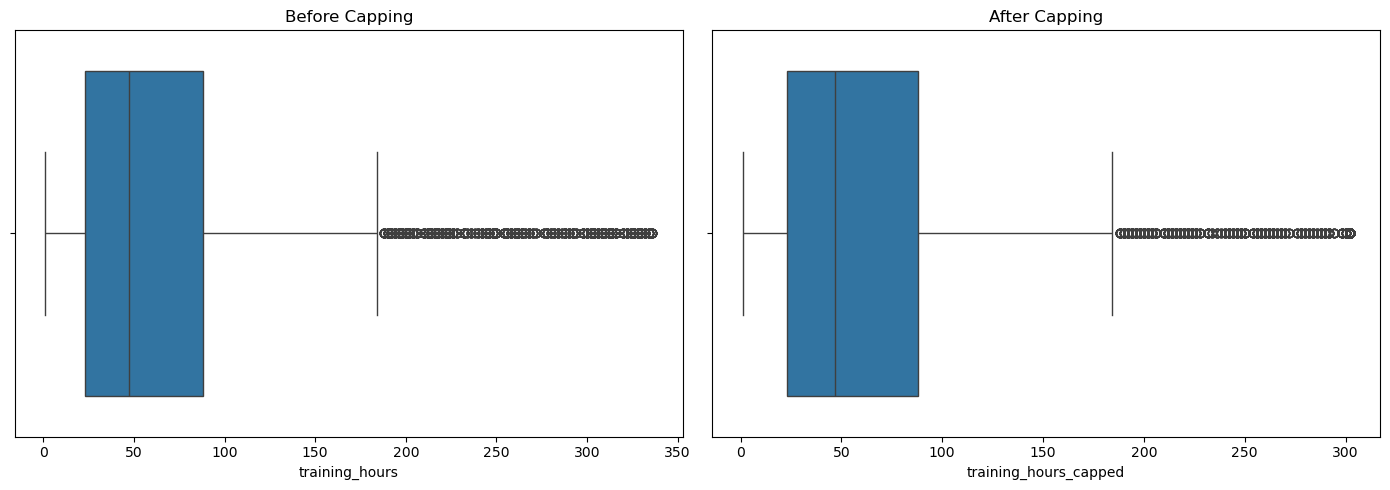

In [12]:
# Cell 11: Handle outliers (optional but recommended)
print("Training Hours Statistics:")
print(train_df['training_hours'].describe())

# Cap extreme outliers at 99th percentile
q99 = train_df['training_hours'].quantile(0.99)
print(f"\n99th percentile of training_hours: {q99}")

# Apply capping
train_df['training_hours_capped'] = train_df['training_hours'].clip(upper=q99)
test_df['training_hours_capped'] = test_df['training_hours'].clip(upper=q99)

print("\nAfter capping:")
print(train_df['training_hours_capped'].describe())

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_df, x='training_hours', ax=axes[0])
axes[0].set_title('Before Capping')
sns.boxplot(data=train_df, x='training_hours_capped', ax=axes[1])
axes[1].set_title('After Capping')
plt.tight_layout()
plt.show()

In [13]:
# Cell 12: Save cleaned data
# Drop original experience column and use cleaned version
train_df_clean = train_df.drop('experience', axis=1)
test_df_clean = test_df.drop('experience', axis=1)

# Save to CSV
train_df_clean.to_csv('train_cleaned_v2.csv', index=False)
test_df_clean.to_csv('test_cleaned_v2.csv', index=False)

print("✅ Cleaned data saved!")
print("   - train_cleaned_v2.csv")
print("   - test_cleaned_v2.csv")

✅ Cleaned data saved!
   - train_cleaned_v2.csv
   - test_cleaned_v2.csv


In [14]:
# Cell 13: Define features
# Note: We'll use training_hours_capped instead of training_hours
features = [
    'city_development_index',
    'gender',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'experience_cleaned',
    'company_size',
    'company_type',
    'last_new_job',
    'training_hours_capped',  # Using capped version
    'experience_ratio',
    'training_per_experience',
    'has_relevant_exp',
    'exp_category'
]

X = train_df_clean[features]
y = train_df_clean['target']
X_test = test_df_clean[features]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Test shape: {X_test.shape}")

Features shape: (19158, 15)
Target shape: (19158,)
Test shape: (2129, 15)


In [15]:
# Cell 14: Split data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")

Training: 15326 samples
Validation: 3832 samples


In [16]:
# Cell 15: Identify numeric and categorical columns
numeric_cols = [
    'city_development_index',
    'experience_cleaned',
    'training_hours_capped',
    'experience_ratio',
    'training_per_experience',
    'has_relevant_exp'
]

categorical_cols = [
    'gender',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'company_size',
    'company_type',
    'last_new_job',
    'exp_category'
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['city_development_index', 'experience_cleaned', 'training_hours_capped', 'experience_ratio', 'training_per_experience', 'has_relevant_exp']
Categorical columns: ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type', 'last_new_job', 'exp_category']


In [17]:
# Cell 16: Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("✅ Preprocessing pipeline created!")

✅ Preprocessing pipeline created!


In [18]:
# Cell 17: Define models
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # ≈ 3.0

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),  # doesn't support class_weight, left as-is
    'SVM': SVC(random_state=42, probability=True, kernel='rbf', class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100, scale_pos_weight=scale_pos_weight)
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Naive Bayes
  - SVM
  - XGBoost


In [19]:
# Cell 18: Train all models
results = []
trained_models = {}

print("Training models...\n")

for name, model in models.items():
    print(f"Training: {name}")
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'AUC': auc
    })
    
    trained_models[name] = pipeline
    
    print(f"  ✅ Accuracy: {accuracy:.4f}, AUC: {auc:.4f}\n")

Training models...

Training: Logistic Regression
  ✅ Accuracy: 0.7338, AUC: 0.7908

Training: Decision Tree
  ✅ Accuracy: 0.7623, AUC: 0.7756

Training: Random Forest
  ✅ Accuracy: 0.7782, AUC: 0.8120

Training: Naive Bayes
  ✅ Accuracy: 0.6962, AUC: 0.7119

Training: SVM
  ✅ Accuracy: 0.7487, AUC: 0.8033

Training: XGBoost
  ✅ Accuracy: 0.7782, AUC: 0.8021



In [20]:
# Cell 19: Show results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC', ascending=False)

print("="*60)
print("Model Results (Sorted by AUC)")
print("="*60)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   AUC: {results_df.iloc[0]['AUC']:.4f}")

Model Results (Sorted by AUC)
                 Model  Accuracy       AUC
2        Random Forest  0.778184  0.812023
4                  SVM  0.748695  0.803250
5              XGBoost  0.778184  0.802053
0  Logistic Regression  0.733820  0.790824
1        Decision Tree  0.762265  0.775578
3          Naive Bayes  0.696242  0.711912

🏆 Best Model: Random Forest
   Accuracy: 0.7782
   AUC: 0.8120


Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.78      0.84      2877
         1.0       0.54      0.78      0.64       955

    accuracy                           0.78      3832
   macro avg       0.73      0.78      0.74      3832
weighted avg       0.82      0.78      0.79      3832


Confusion Matrix:
[[2241  636]
 [ 214  741]]


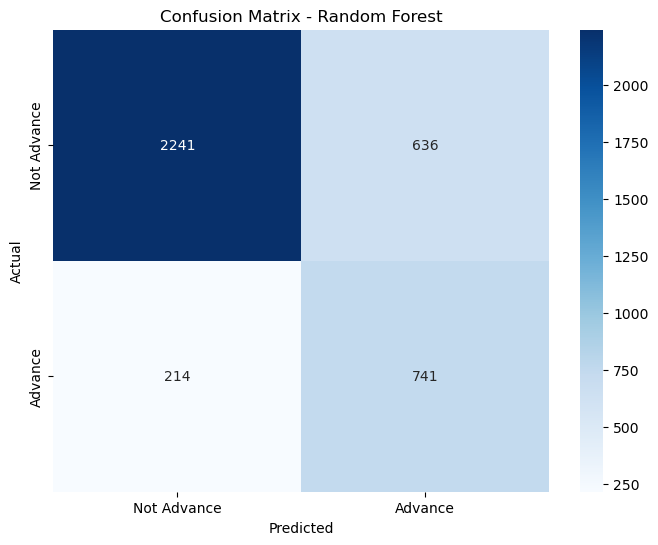

In [21]:
# Cell 20: Evaluate best model in detail
y_pred_best = best_model.predict(X_val)

print("Classification Report:")
print(classification_report(y_val, y_pred_best))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred_best)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Advance', 'Advance'],
            yticklabels=['Not Advance', 'Advance'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

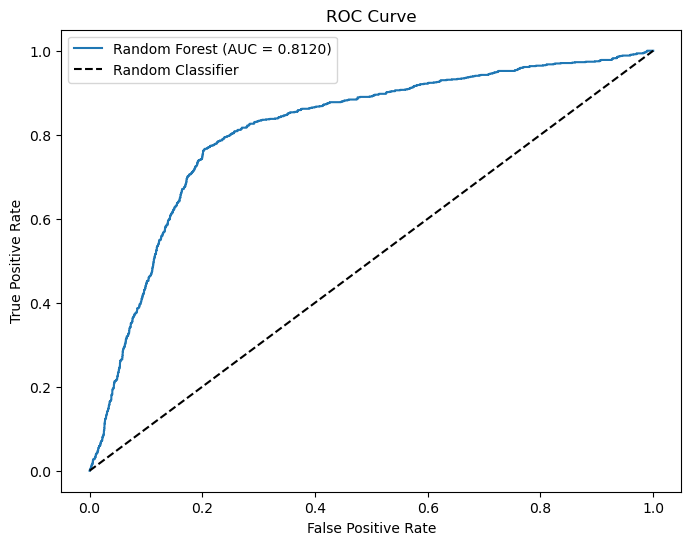

In [22]:
# Cell 21: Plot ROC curve
y_proba_best = best_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {results_df.iloc[0]["AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Feature Importance Analysis:

Top 10 Features:
                     Feature  Importance
0     city_development_index    0.314301
37      company_size_unknown    0.102329
3           experience_ratio    0.064797
44      company_type_unknown    0.062219
1         experience_cleaned    0.047258
4    training_per_experience    0.040728
2      training_hours_capped    0.036638
43      company_type_pvt ltd    0.031728
16  education_level_graduate    0.021825
52       exp_category_expert    0.020037


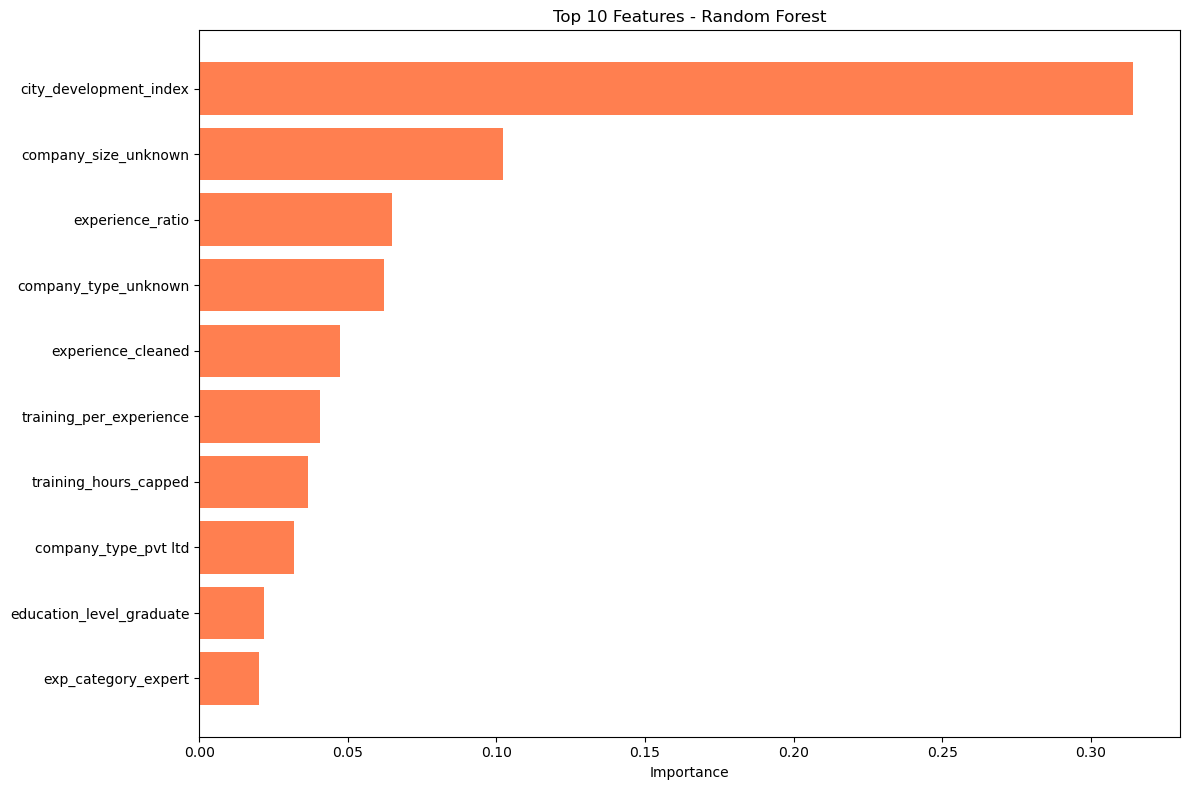

In [23]:
# Cell 22: Feature importance (if applicable)
if best_model_name in ['Random Forest', 'Decision Tree', 'XGBoost']:
    print("\nFeature Importance Analysis:")
    
    # Get feature names after preprocessing
    feature_names = []
    for col in numeric_cols:
        feature_names.append(col)
    
    # Get categorical feature names from encoder
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    for i, col in enumerate(categorical_cols):
        categories = cat_encoder.categories_[i]
        for cat in categories:
            feature_names.append(f"{col}_{cat}")
    
    importances = best_model.named_steps['classifier'].feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names[:len(importances)],
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Features:")
    print(importance_df.head(10))
    
    # Plot
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(10)
    plt.barh(top_features['Feature'], top_features['Importance'], color='coral')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [24]:
# Cell 23: Predict on test data
print("Predicting on test data...")
test_predictions = best_model.predict(X_test)
test_probabilities = best_model.predict_proba(X_test)[:, 1]

submission_df = pd.DataFrame({
    'enrollee_id': test_df['enrollee_id'],
    'prediction': test_predictions,
    'probability': test_probabilities
})

print("\nFirst 10 predictions:")
print(submission_df.head(10))

print(f"\nPrediction distribution:")
print(submission_df['prediction'].value_counts())

# Save predictions
submission_df.to_csv('submission_v2.csv', index=False)
print("\n✅ submission_v2.csv saved!")

Predicting on test data...

First 10 predictions:
   enrollee_id  prediction  probability
0        32403         0.0     0.368021
1         9858         0.0     0.343649
2        31806         1.0     0.546912
3        27385         0.0     0.184820
4        27724         0.0     0.207418
5          217         1.0     0.640332
6        21465         1.0     0.750572
7        27302         1.0     0.738607
8        12994         1.0     0.589331
9        16287         1.0     0.547143

Prediction distribution:
prediction
0.0    1400
1.0     729
Name: count, dtype: int64

✅ submission_v2.csv saved!


🏆 TOP 10 RECOMMENDED CANDIDATES
 Candidate ID  Probability  City Index  Experience  Training Hours
        32795       0.8598       0.527         3.0              41
        21968       0.8584       0.624         0.0              50
        18519       0.8552       0.624         4.0              53
          462       0.8490       0.550         5.0              46
         7679       0.8389       0.624         2.0              66
         3432       0.8388       0.550         1.0              44
        17221       0.8387       0.624         4.0              36
        32233       0.8378       0.550         0.0              81
        27297       0.8359       0.624         1.0              34
        31481       0.8351       0.624         3.0              23

✅ top_10_candidates_v2.csv saved!


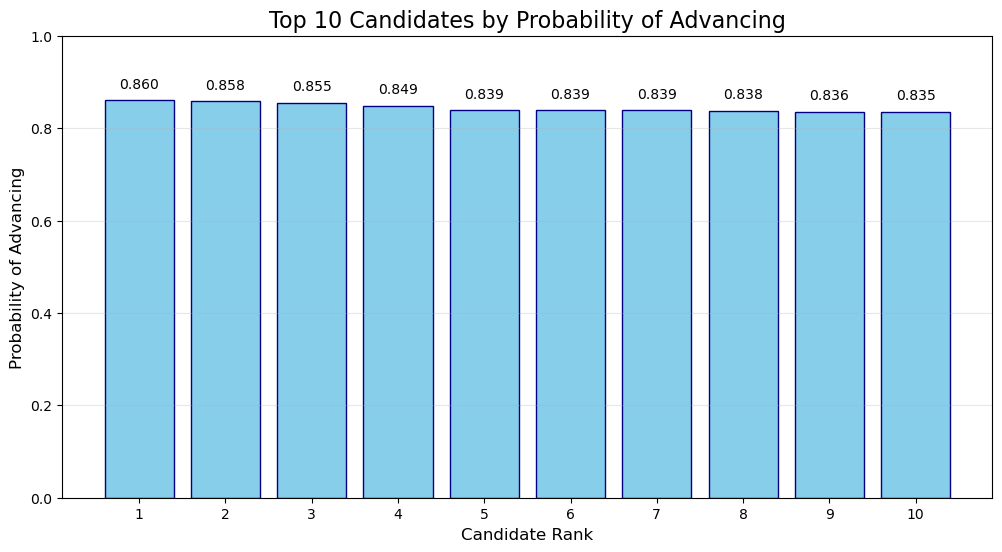

In [25]:
# Cell 24: Get top 10 candidates
top_10 = submission_df.sort_values('probability', ascending=False).head(10)

top_10_info = top_10.merge(
    test_df[['enrollee_id', 'city_development_index', 'experience_cleaned', 'training_hours']],
    on='enrollee_id',
    how='left'
)

print("="*60)
print("🏆 TOP 10 RECOMMENDED CANDIDATES")
print("="*60)

display_cols = ['enrollee_id', 'probability', 'city_development_index', 'experience_cleaned', 'training_hours']
top_10_display = top_10_info[display_cols].copy()
top_10_display['probability'] = top_10_display['probability'].round(4)
top_10_display.columns = ['Candidate ID', 'Probability', 'City Index', 'Experience', 'Training Hours']

print(top_10_display.to_string(index=False))

top_10_info.to_csv('top_10_candidates_v2.csv', index=False)
print("\n✅ top_10_candidates_v2.csv saved!")

# Visualize top 10
plt.figure(figsize=(12, 6))
bars = plt.bar(range(1, 11), top_10_info['probability'], color='skyblue', edgecolor='navy')
plt.title('Top 10 Candidates by Probability of Advancing', fontsize=16)
plt.xlabel('Candidate Rank', fontsize=12)
plt.ylabel('Probability of Advancing', fontsize=12)
plt.xticks(range(1, 11))
plt.ylim(0, 1)

for bar, prob in zip(bars, top_10_info['probability']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{prob:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.show()

In [26]:
# Cell 25: Save model and final summary
import joblib

# Save model
joblib.dump(best_model, 'best_model_v2.pkl')
joblib.dump(preprocessor, 'preprocessor_v2.pkl')

print("✅ Model saved successfully!")
print("   - best_model_v2.pkl")
print("   - preprocessor_v2.pkl")

print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"""
📊 Data:
   - Training samples: {len(train_df)}
   - Test samples: {len(test_df)}
   - Features used: {len(features)}
   - New features added: experience_ratio, training_per_experience, has_relevant_exp, exp_category

🏆 Best Model: {best_model_name}
   - Accuracy: {results_df.iloc[0]['Accuracy']:.4f}
   - AUC: {results_df.iloc[0]['AUC']:.4f}

📈 Predictions:
   - Total predictions: {len(submission_df)}
   - Will advance: {submission_df['prediction'].sum()}
   - Will not advance: {len(submission_df) - submission_df['prediction'].sum()}
   - Advance rate: {submission_df['prediction'].mean() * 100:.2f}%

🎯 Files Generated:
   ✅ train_cleaned_v2.csv
   ✅ test_cleaned_v2.csv
   ✅ submission_v2.csv
   ✅ top_10_candidates_v2.csv
   ✅ best_model_v2.pkl
   ✅ preprocessor_v2.pkl

🚀 Next Step: Update Streamlit App
   1. Update app.py to load best_model_v2.pkl
   2. Update feature list in app.py
""")

print("="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

✅ Model saved successfully!
   - best_model_v2.pkl
   - preprocessor_v2.pkl

PROJECT SUMMARY

📊 Data:
   - Training samples: 19158
   - Test samples: 2129
   - Features used: 15
   - New features added: experience_ratio, training_per_experience, has_relevant_exp, exp_category

🏆 Best Model: Random Forest
   - Accuracy: 0.7782
   - AUC: 0.8120

📈 Predictions:
   - Total predictions: 2129
   - Will advance: 729.0
   - Will not advance: 1400.0
   - Advance rate: 34.24%

🎯 Files Generated:
   ✅ train_cleaned_v2.csv
   ✅ test_cleaned_v2.csv
   ✅ submission_v2.csv
   ✅ top_10_candidates_v2.csv
   ✅ best_model_v2.pkl
   ✅ preprocessor_v2.pkl

🚀 Next Step: Update Streamlit App
   1. Update app.py to load best_model_v2.pkl
   2. Update feature list in app.py

✅ PROJECT COMPLETED SUCCESSFULLY!
